# ZADATAK (Vježba 8): Neuralne mreže - MLP

**Univerzitet u Zenici**  
**Politehnički fakultet**  
**Odsjek:** Softversko inženjerstvo  
**Predmet:** Rudarenje podataka  
**Datum:** 13.04.2026.  
**Student:** Delaida Muminović  
**Broj indeksa:** 138

---

U ovom zadatku radim klasifikaciju pomoću `MLPClassifier` modela. Pratim standardni tok rada: učitavanje podataka, kratka EDA analiza, skaliranje podataka pomoću `StandardScaler`, poređenje dvije MLP arhitekture, prikaz F1 score-a, `classification_report`, krive učenja i završni komentar.

Za dataset sam odabrala **Sign Language MNIST** sa Kaggle-a: https://www.kaggle.com/datamunge/sign-language-mnist. U njemu su slike američkog znakovnog jezika zapisane u CSV formatu. Prva kolona je `label`, a ostalih 784 kolone predstavljaju piksele slike dimenzija 28x28. Iako bi za slike prirodniji izbor bio CNN, ovaj dataset mi odgovara za ovu vježbu jer ima numeričke feature-e i klasifikacijski target, pa se može direktno koristiti za MLP (također i za planirane vježbe i zadaće ubuduće, i lakšeg praćenja na jednom dataset-u).

## 1. Uvoz biblioteka

U ovom dijelu uvozimo biblioteke koje se koriste za obradu podataka, vizualizaciju, skaliranje, treniranje MLP modela i evaluaciju rezultata.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Biblioteke su uspješno učitane.")

Biblioteke su uspješno učitane.


## 2. Učitavanje dataseta

Prvo pokušavamo učitati CSV fajlove lokalno iz foldera `data/`, jer je to najstabilnije kada rad pokrećem na svom računaru. Ako lokalni fajlovi nisu dostupni, koriste se Google Drive linkove koje sam dodala kao fallback izvor podataka. U kodu sam dodala i provjeru koja automatski zamijeni train i test set ako su fajlovi slučajno učitani obrnutim redoslijedom.

**Napomena o fajlovima:** CSV fajlovi za Sign Language MNIST su veliki, pa ih nisam planirala commitati na GitHub. Zbog toga sam dodala Google Drive linkove u notebook: ako su fajlovi već skinuti u `data/` folder, učitavaju se lokalno; ako nisu, podaci se mogu učitati preko Google Drive linkova. (Drive datoteke su podešene da im se može pristupiti preko linka)

In [2]:
DATA_DIR = Path("data")
LOCAL_TRAIN = DATA_DIR / "sign_mnist_train.csv"
LOCAL_TEST = DATA_DIR / "sign_mnist_test.csv"

# Google Drive linkove ostavljam kao fallback jer su CSV fajlovi preveliki za GitHub.
# Namjerno ih navodim u ispravnom redoslijedu: veći fajl je train, manji je test.
TRAIN_URL = "https://drive.google.com/uc?export=download&id=1KM269MKU0v-vZ5EnOw2NQVxORMI6quA6"
TEST_URL = "https://drive.google.com/uc?export=download&id=1T96w6lujBM1WK_tDcub5gyE87A2dFpzo"


def load_csv(local_path, fallback_url):
    if local_path.exists():
        print(f"Učitavam lokalni fajl: {local_path}")
        return pd.read_csv(local_path)

    print(f"Lokalni fajl nije pronađen ({local_path}). Učitavam preko Google Drive linka...")
    return pd.read_csv(fallback_url)


df_train = load_csv(LOCAL_TRAIN, TRAIN_URL)
df_test = load_csv(LOCAL_TEST, TEST_URL)

if len(df_train) < len(df_test):
    print("Napomena: train set ima manje redova od test seta. Automatski ih zamjenjujem.")
    df_train, df_test = df_test, df_train

print(f"Train set: {df_train.shape[0]:,} redova, {df_train.shape[1]:,} kolona")
print(f"Test set:  {df_test.shape[0]:,} redova, {df_test.shape[1]:,} kolona")

display(df_train.head())

Učitavam lokalni fajl: data/sign_mnist_train.csv


Učitavam lokalni fajl: data/sign_mnist_test.csv


Train set: 27,455 redova, 785 kolona
Test set:  7,172 redova, 785 kolona


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


## 3. Kratka EDA analiza

Ovdje se vrši provjerava osnovne strukture dataseta: broj feature-a, nedostajuće vrijednosti, broj klasa i raspodjelu labela. Kod ovog dataseta labele idu od `0` do `24`, ali bez slova `J`, jer se `J` u znakovnom jeziku izvodi pokretom i ne predstavlja se jednom statičnom slikom.

Kolone:
- Target kolona: label
- Broj numeričkih feature-a: 784
- Nedostajuće vrijednosti u train setu: 0
- Nedostajuće vrijednosti u test setu:  0


,label,slovo,train_broj,test_broj
0,0,A,1126,331
1,1,B,1010,432
2,2,C,1144,310
3,3,D,1196,245
4,4,E,957,498
5,5,F,1204,247
6,6,G,1090,348
7,7,H,1013,436
8,8,I,1162,288
9,10,K,1114,331


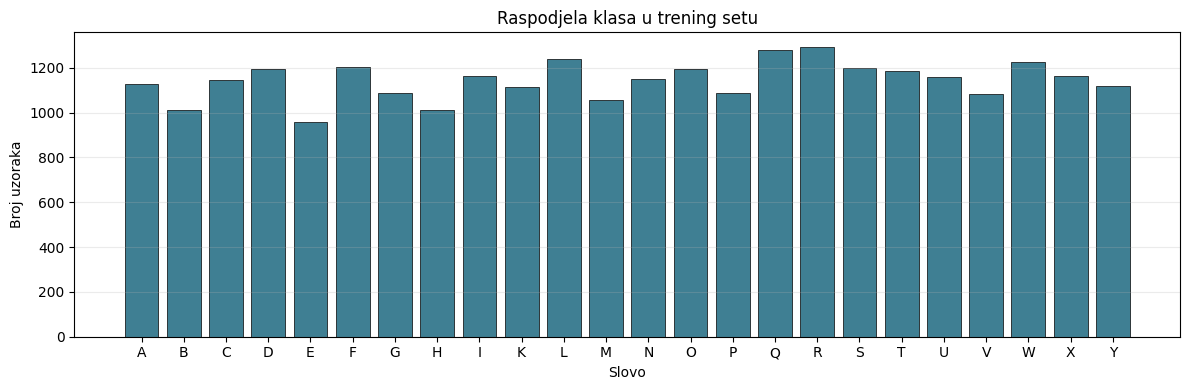

In [3]:
label_to_letter = {i: chr(ord("A") + i) for i in range(26)}

def label_name(label):
    return f"{label_to_letter.get(int(label), '?')} ({int(label)})"

print("Kolone:")
print(f"- Target kolona: label")
print(f"- Broj numeričkih feature-a: {df_train.shape[1] - 1}")
print(f"- Nedostajuće vrijednosti u train setu: {int(df_train.isna().sum().sum())}")
print(f"- Nedostajuće vrijednosti u test setu:  {int(df_test.isna().sum().sum())}")

train_counts = df_train["label"].value_counts().sort_index()
test_counts = df_test["label"].value_counts().sort_index()
class_summary = pd.DataFrame({
    "label": train_counts.index,
    "slovo": [label_to_letter[i] for i in train_counts.index],
    "train_broj": train_counts.values,
    "test_broj": test_counts.reindex(train_counts.index, fill_value=0).values,
})

display(class_summary)

plt.figure(figsize=(12, 4))
plt.bar(class_summary["slovo"], class_summary["train_broj"], color="#3f7f93", edgecolor="black", linewidth=0.5)
plt.title("Raspodjela klasa u trening setu")
plt.xlabel("Slovo")
plt.ylabel("Broj uzoraka")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Prikaz nekoliko slika

Pošto su slike zapisane kao 784 odvojene kolone piksela, ovdje nekoliko redova vraćam u oblik `28x28`. Na taj način mogu vizualno provjeriti da podaci zaista predstavljaju slike znakova, a ne samo anonimnu tabelu brojeva.

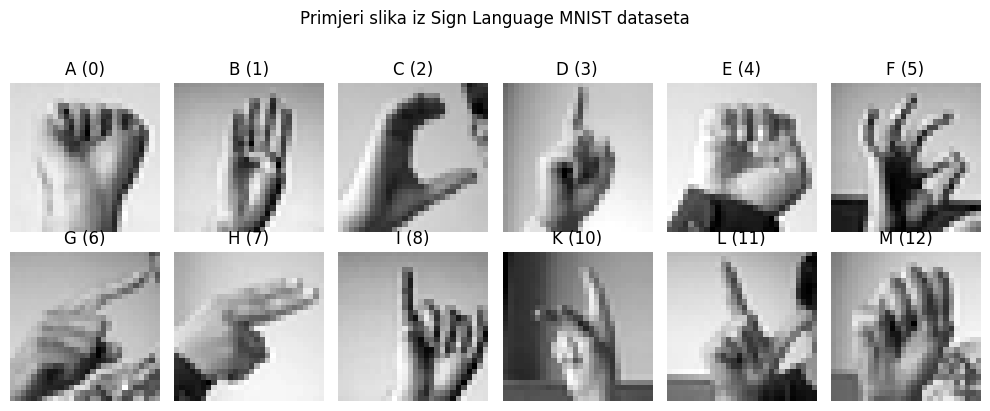

In [4]:
X_preview = df_train.drop(columns="label")
y_preview = df_train["label"].astype(int)

sample_labels = sorted(y_preview.unique())[:12]
fig, axes = plt.subplots(2, 6, figsize=(10, 4))

for ax, label in zip(axes.ravel(), sample_labels):
    row_index = y_preview[y_preview == label].index[0]
    image = X_preview.loc[row_index].to_numpy(dtype=float).reshape(28, 28)
    ax.imshow(image, cmap="gray")
    ax.set_title(label_name(label))
    ax.axis("off")

plt.suptitle("Primjeri slika iz Sign Language MNIST dataseta", y=1.03)
plt.tight_layout()
plt.show()

## 5. Priprema podataka i StandardScaler

U ovom koraku odvaja se target kolona `label` od numeričkih piksela. `StandardScaler` fitujem samo na trening podacima, a zatim isti scaler se primjenjuje na test set. Ovo radimo zato da test podaci ne utiču na preprocessing i da evaluacija ostane korektna.

In [5]:
X_train = df_train.drop(columns="label").astype("float32")
y_train = df_train["label"].astype(int)
X_test = df_test.drop(columns="label").astype("float32")
y_test = df_test["label"].astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"Prosjek nakon skaliranja (prvih 5 feature-a): {np.round(X_train_scaled.mean(axis=0)[:5], 3)}")
print(f"Std nakon skaliranja (prvih 5 feature-a):     {np.round(X_train_scaled.std(axis=0)[:5], 3)}")

X_train: (27455, 784), y_train: (27455,)
X_test:  (7172, 784), y_test:  (7172,)
Prosjek nakon skaliranja (prvih 5 feature-a): [ 0. -0.  0.  0. -0.]
Std nakon skaliranja (prvih 5 feature-a):     [1. 1. 1. 1. 1.]


## 6. Bonus: MLP bez skaliranja

Za bonus dio provjeravam šta se desi kada MLP treniram nad sirovim vrijednostima piksela `0-255`, bez `StandardScaler` pretprocesiranja. Koristim malu arhitekturu kako bih rezultat mogla direktno uporediti sa skaliranom verzijom.

In [6]:
mlp_no_scaler = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=40,
    batch_size=256,
    early_stopping=True,
    n_iter_no_change=5,
    random_state=RANDOM_STATE,
)

mlp_no_scaler.fit(X_train, y_train)
y_pred_no_scaler = mlp_no_scaler.predict(X_test)
f1_no_scaler = f1_score(y_test, y_pred_no_scaler, average="weighted")

print(f"F1 score bez StandardScaler-a: {f1_no_scaler:.4f}")
print(f"Broj epoha bez skaliranja: {mlp_no_scaler.n_iter_}")

F1 score bez StandardScaler-a: 0.0016
Broj epoha bez skaliranja: 7


## 7. Treniranje i poređenje dvije MLP arhitekture

Upoređujem dvije arhitekture:

- **Mala mreža:** jedan skriveni sloj sa 50 neurona.
- **Veća mreža:** dva skrivena sloja sa 128 i 64 neurona.

Oba modela treniram nad istim skaliranim podacima i koristim isti `random_state`, kako bi poređenje bilo vjerodostojno. U tabeli ispod pratim F1 score, broj epoha i završnu vrijednost loss funkcije.

In [7]:
architectures = {
    "Mala mreža (50)": (50,),
    "Veća mreža (128, 64)": (128, 64),
}

trained_models = {}
results = []

for name, hidden_layers in architectures.items():
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        max_iter=60,
        batch_size=256,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=8,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred, average="weighted")

    trained_models[name] = {"model": model, "predictions": y_pred}
    results.append({
        "model": name,
        "hidden_layer_sizes": hidden_layers,
        "F1_weighted": round(f1, 4),
        "epohe": model.n_iter_,
        "final_loss": round(model.loss_curve_[-1], 4),
    })

results_df = pd.DataFrame(results).sort_values("F1_weighted", ascending=False).reset_index(drop=True)
display(results_df)

best_name = results_df.loc[0, "model"]
best_model = trained_models[best_name]["model"]
best_pred = trained_models[best_name]["predictions"]

print(f"Najbolji model prema weighted F1: {best_name}")

,model,hidden_layer_sizes,F1_weighted,epohe,final_loss
0,"Veća mreža (128, 64)","(128, 64)",0.7675,12,0.0013
1,Mala mreža (50),"(50,)",0.7435,16,0.0049


Najbolji model prema weighted F1: Veća mreža (128, 64)


## 8. Classification report za najbolji model

Nakon poređenja arhitektura biram model sa najboljim weighted F1 score-om i za njega prikazujem detaljan `classification_report`. Umjesto samih brojeva labela dodajem i slova, jer je tako lakše pročitati koje znakove model bolje ili lošije prepoznaje.

In [8]:
report_labels = sorted(y_test.unique())
report_names = [label_name(label) for label in report_labels]

print(classification_report(
    y_test,
    best_pred,
    labels=report_labels,
    target_names=report_names,
    zero_division=0,
))

              precision    recall  f1-score   support

       A (0)       0.88      1.00      0.93       331
       B (1)       1.00      0.87      0.93       432
       C (2)       0.86      1.00      0.92       310
       D (3)       0.77      0.89      0.82       245
       E (4)       0.86      0.96      0.91       498
       F (5)       0.87      0.85      0.86       247
       G (6)       0.76      0.79      0.78       348
       H (7)       0.91      0.86      0.88       436
       I (8)       0.83      0.73      0.78       288
      K (10)       0.80      0.69      0.74       331
      L (11)       0.74      0.96      0.83       209
      M (12)       0.81      0.53      0.64       394
      N (13)       0.64      0.70      0.67       291
      O (14)       0.94      0.66      0.78       246
      P (15)       1.00      0.97      0.98       347
      Q (16)       0.56      0.87      0.68       164
      R (17)       0.23      0.44      0.30       144
      S (18)       0.55    

## 9. Confusion matrix

Ovdje prikazujem matricu konfuzije za najbolji model. Ona pomaže da vidimo koje znakove model najčešće zamjenjuje. Kod znakovnog jezika je očekivano da neke klase budu teže za razlikovanje, jer položaji ruke mogu biti vrlo slični.

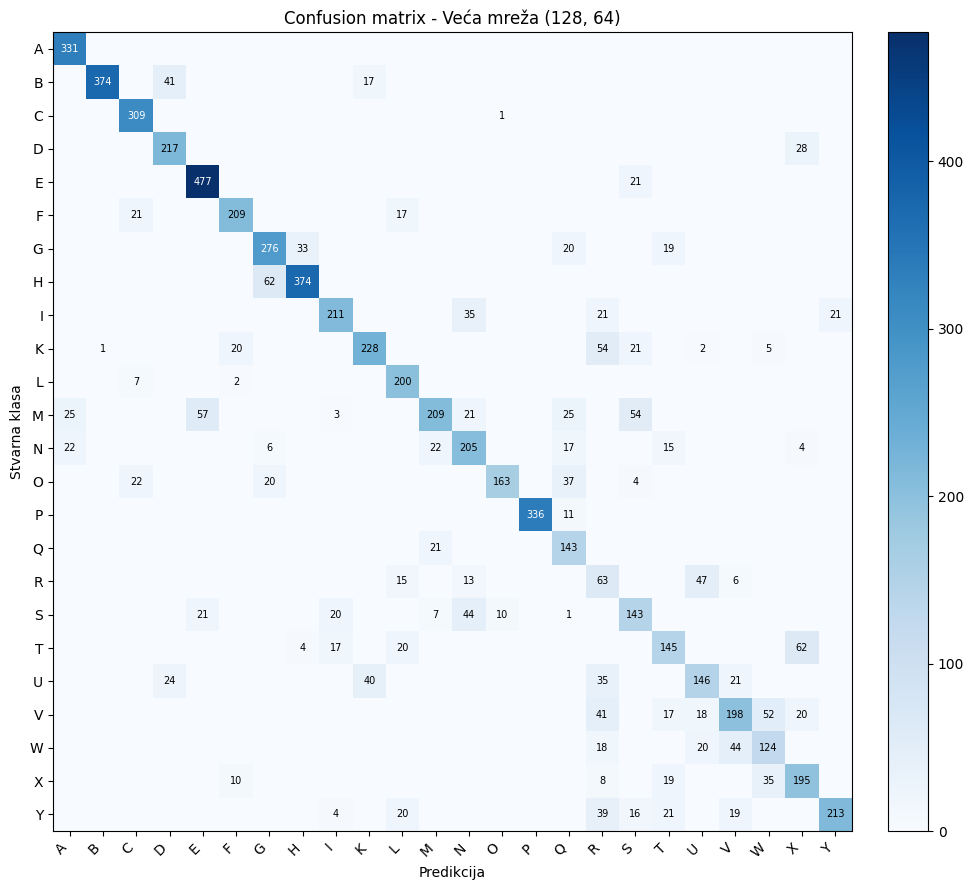

In [9]:
cm = confusion_matrix(y_test, best_pred, labels=report_labels)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_title(f"Confusion matrix - {best_name}")
ax.set_xlabel("Predikcija")
ax.set_ylabel("Stvarna klasa")
ax.set_xticks(range(len(report_labels)))
ax.set_yticks(range(len(report_labels)))
ax.set_xticklabels([label_to_letter[i] for i in report_labels], rotation=45, ha="right")
ax.set_yticklabels([label_to_letter[i] for i in report_labels])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() * 0.55 else "black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 10. Krive učenja

Na kraju prikazujemo krive učenja za obje MLP arhitekture. Pratim kako se `loss_curve_` mijenja kroz epohe: ako loss opada, model uči; ako stagnira ili oscilira, to bi značilo da arhitektura ili parametri treniranja nisu idealni.

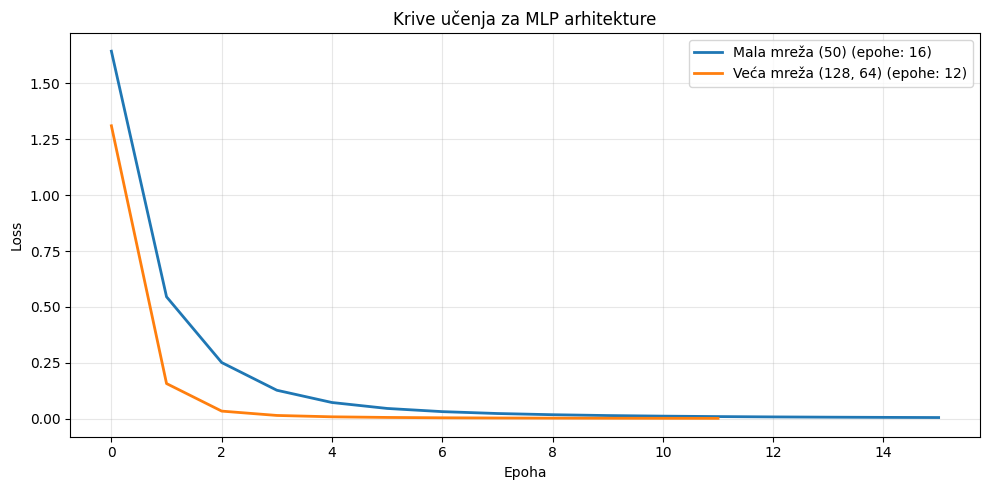

In [10]:
plt.figure(figsize=(10, 5))

for name, values in trained_models.items():
    model = values["model"]
    plt.plot(model.loss_curve_, linewidth=2, label=f"{name} (epohe: {model.n_iter_})")

plt.title("Krive učenja za MLP arhitekture")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Komentar i analiza

**StandardScaler:** Primijetila sam veliku razliku između modela bez skaliranja i modela sa skaliranjem. Kada MLP koristi sirove vrijednosti piksela `0-255`, optimizacija je mnogo teža i F1 score je veoma nizak. Nakon `StandardScaler` transformacije feature-i imaju približno mean `0` i standardnu devijaciju `1`, pa se težine stabilnije ažuriraju tokom backpropagation koraka.

**Da li je veća mreža uvijek bolja?** Ne mora biti. U mom slučaju veća mreža `(128, 64)` daje bolji weighted F1 score od manje mreže `(50,)`, ali to ne znači da je veća arhitektura uvijek bolji izbor. Ako je dataset manji ili šumniji, veća mreža može pretrenirati podatke ili duže trenirati bez stvarnog poboljšanja na test setu. Zbog toga sam obje arhitekture uporedila preko istog F1 score-a na istom test setu.

**Koliko epoha je trebalo?** Broj epoha je prikazan u tabeli rezultata kroz `n_iter_`. Pošto koristim `early_stopping=True`, treniranje se može zaustaviti prije `max_iter` ako se validacioni rezultat više ne popravlja.

**Je li dataset dobar za zahtjeve zadatka?** Smatram da jeste. Dataset ima numeričke feature-e, klasifikacijski target i nije Iris, što zadatak eksplicitno traži. Ipak, važno je naglasiti da je ovo slikovni dataset u tabelarnom obliku. Za ozbiljniji rad nad slikama prirodniji izbor bi bio CNN, ali za ovu vježbu MLP je prihvatljiv jer je cilj razumjeti standardizaciju, različite arhitekture, F1 score i krive učenja. Također, ovaj dataset je izabran jer je planirano da se s njim prate vježbe, odnosno praktični zadaci do kraja.